In [8]:
# ============================
# ImageNet folder -> coarse category counts + dict for plotting
# ============================
import os
import re
import json
from collections import Counter, defaultdict
from pathlib import Path

# ---- 0) Config: your images folder
IMG_DIR = Path("../benchmarks/vggnet16_benchmark2022/imagenet-sample")  # <-- CHANGE ME

# ---- 1) (one-time) deps
# pip install nltk requests tqdm
import requests
from tqdm import tqdm
import nltk
from nltk.corpus import wordnet as wn

# Download WordNet data if missing
try:
    wn.synsets("dog")
except LookupError:
    nltk.download("wordnet")
    nltk.download("omw-1.4")

# ---- 2) Download ImageNet class index (wnid -> human label)
# This file is widely used (Keras / torchvision style) to map ImageNet-1k classes to names.
# We'll build wnid -> label string.
CLASS_INDEX_URL = (
    "https://raw.githubusercontent.com/raghakot/keras-vis/master/resources/imagenet_class_index.json"
)

def load_wnid_to_label(cache_path: Path = Path("imagenet_class_index.json")):
    if not cache_path.exists():
        r = requests.get(CLASS_INDEX_URL, timeout=30)
        r.raise_for_status()
        cache_path.write_text(r.text, encoding="utf-8")

    class_index = json.loads(cache_path.read_text(encoding="utf-8"))
    wnid_to_label = {}
    for _k, (wnid, label_str) in class_index.items():
        # label_str might be like "robin, American robin, Turdus migratorius"
        # We'll keep the first short label before comma: "robin"
        short = label_str.split(",")[0].strip()
        wnid_to_label[wnid] = short
    return wnid_to_label

WNID_TO_LABEL = load_wnid_to_label()

# ---- 3) Helpers to extract wnid from filename OR parent folder
WNID_RE = re.compile(r"(n\d{8})")

def extract_wnid(path: Path) -> str | None:
    # Try filename first
    m = WNID_RE.search(path.name)
    if m:
        return m.group(1)
    # Try parent directories (common ImageNet layout: .../n01443537/xxx.JPEG)
    for p in path.parents:
        m = WNID_RE.search(p.name)
        if m:
            return m.group(1)
    return None

def wnid_to_wordnet_synset(wnid: str):
    # wnid like "n01443537" -> offset 1443537 noun synset
    offset = int(wnid[1:])
    return wn.synset_from_pos_and_offset("n", offset)

def synset_has_ancestor(synset, ancestor_name: str) -> bool:
    """ancestor_name like 'bird.n.01'"""
    ancestor = wn.synset(ancestor_name)
    # closure = synset + all hypernyms recursively
    for s in synset.closure(lambda x: x.hypernyms()):
        if s == ancestor:
            return True
    return False
# ---- 4) Coarse clusters: target ~7 buckets
# We keep this intentionally broad and stable for ImageNet-scale analysis.
COARSE_GROUPS = {
    # living things
    "people":   ["person.n.01"],
    "animals":  ["animal.n.01"],
    "plants":   ["plant.n.02"],

    # common “what is it?” buckets
    "food":     ["food.n.01"],
    "vehicles": ["vehicle.n.01"],

    # most ImageNet man-made objects end up here
    "artifacts": ["artifact.n.01"],
}

# Priority matters: if something is both artifact-like and food-like, we want "food", etc.
COARSE_PRIORITY = [
    "people",
    "animals",
    "plants",
    "food",
    "vehicles",
    "artifacts",
]

# ---- 4.5) Merge lexnames (fallback) into the same ~7 buckets
MERGE_COARSE = {
    # living things
    "noun.person": "people",
    "noun.animal": "animals",
    "noun.plant":  "plants",

    # “stuff”
    "noun.food": "food",

    # WordNet tends to put most man-made things as noun.artifact
    "noun.artifact": "artifacts",

    # these are common fallbacks; fold into "other"
    "noun.substance": "other",
    "noun.object": "other",
    "noun.location": "other",
    "noun.quantity": "other",
    "noun.state": "other",
    "noun.time": "other",
    "noun.event": "other",
    "noun.communication": "other",
    "noun.cognition": "other",
}

def normalize_coarse(coarse: str) -> str:
    s = str(coarse).strip().lower()
    s = s.replace("noun.plan", "noun.plant")  # keep your typo fix

    if s in MERGE_COARSE:
        return MERGE_COARSE[s]

    # if any custom buckets slip through, map them
    if s in {"mammals","dogs","cats","birds","fish","insects","reptiles","amphibians"}:
        return "animals"
    if s == "plant":
        return "plants"

    return s if s else "other"

def coarse_category_for_wnid(wnid: str) -> str:
    try:
        syn = wnid_to_wordnet_synset(wnid)
    except Exception:
        return "other"

    for group in COARSE_PRIORITY:
        for anc in COARSE_GROUPS.get(group, []):
            if synset_has_ancestor(syn, anc):
                return group

    # Fallback to WordNet lexname, then normalize into our ~7 buckets
    try:
        return syn.lexname()
    except Exception:
        return "other"

# ---- 5) Walk folder & count
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

files = [p for p in IMG_DIR.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS]

category_counts = Counter()
label_counts = Counter()
category_to_labels = defaultdict(Counter)   # for plotting later: category -> {label -> count}
wnid_counts = Counter()

for p in tqdm(files, desc="Scanning images"):
    wnid = extract_wnid(p)
    if not wnid:
        continue

    wnid_counts[wnid] += 1

    label = WNID_TO_LABEL.get(wnid, wnid)  # fallback to wnid if unknown
    coarse = coarse_category_for_wnid(wnid)
    coarse = normalize_coarse(coarse)

    category_counts[coarse] += 1
    label_counts[label] += 1
    category_to_labels[coarse][label] += 1

# Convert defaultdict(Counter) -> normal dict for JSON / reuse
category_to_labels = {k: dict(v) for k, v in category_to_labels.items()}

print("\nTop categories:")
for k, v in category_counts.most_common(20):
    print(f"{k:20s} {v}")

# ---- 6) Save dicts you can reuse for plotting
OUT = {
    "total_images": len(files),
    "category_counts": dict(category_counts),
    "label_counts": dict(label_counts),
    "category_to_labels": category_to_labels,
    "wnid_counts": dict(wnid_counts),
}
Path("imagenet_coarse_counts.json").write_text(json.dumps(OUT, indent=2), encoding="utf-8")
print("\nSaved: imagenet_coarse_counts.json")

# Example: what labels exist in "birds"?
if "animals" in category_to_labels:
    top_animal_labels = sorted(category_to_labels["noun.plantt"].items(), key=lambda x: -x[1])[:30]
    print("\nTop animal labels:", top_animal_labels)

Scanning images:   0%|          | 0/1000 [00:00<?, ?it/s]

Scanning images: 100%|██████████| 1000/1000 [00:00<00:00, 18807.86it/s]


Top categories:
artifacts            455
animals              398
vehicles             67
food                 48
other                14
noun.plantt          13
people               3
plants               2

Saved: imagenet_coarse_counts.json

Top animal labels: [('gyromitra', 1), ('earthstar', 1), ('hen-of-the-woods', 1), ('corn', 1), ('coral_fungus', 1), ('buckeye', 1), ('ear', 1), ('agaric', 1), ('rapeseed', 1), ('acorn', 1), ('hip', 1), ('stinkhorn', 1), ('bolete', 1)]


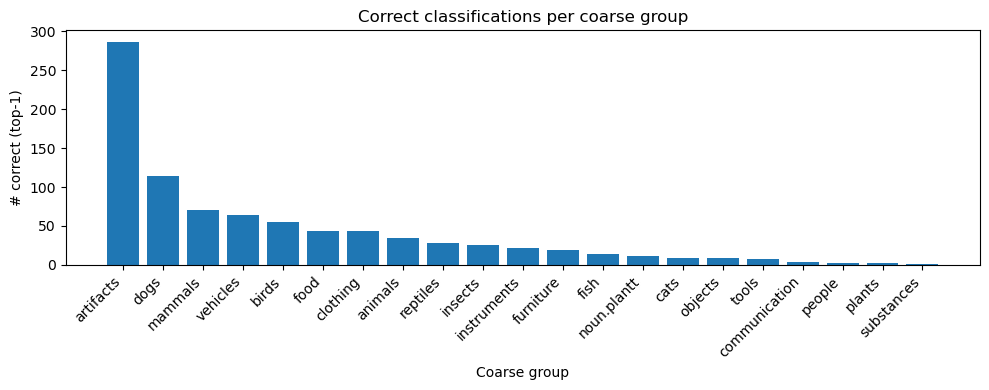

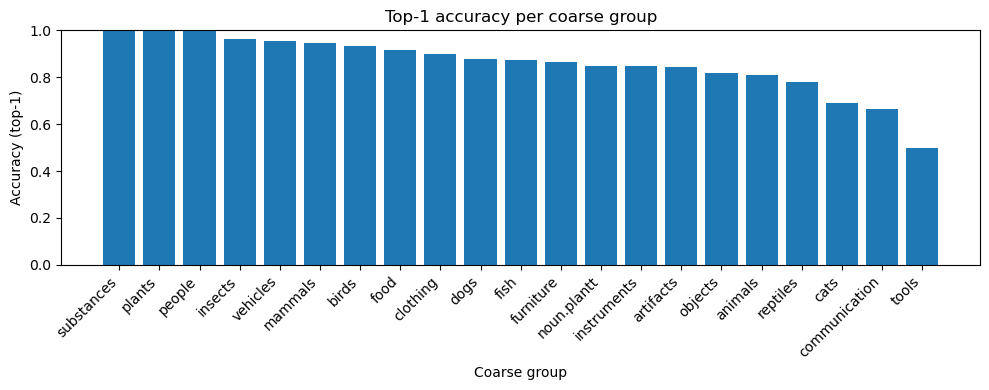

/var/folders/fr/3yg6c3f55w58dtlsnjcqjmth0000gq/T/ipykernel_90014/2080042443.py:78: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=list(order), showfliers=False)


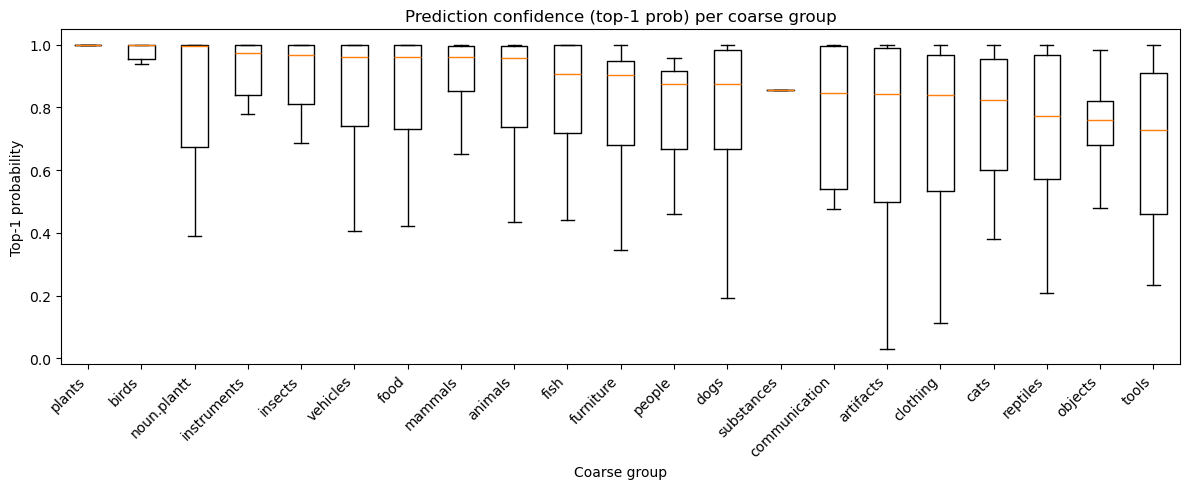

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Load CSV
# --------------------------------------------------

CSV_PATH = Path("onnx_imagenet_eval.csv")  # <-- CHANGE ME (path to your CSV)

df = pd.read_csv(CSV_PATH)

# --- derive wnid from image_path using your existing helper ---
df["image_path"] = df["image_path"].astype(str)
df["wnid"] = df["image_path"].apply(lambda s: extract_wnid(Path(s)))

# --- coarse group from wnid (uses your WordNet logic) ---
df["coarse_raw"] = df["wnid"].apply(lambda w: coarse_category_for_wnid(w) if isinstance(w, str) else "unknown")
df["coarse"] = df["coarse_raw"].apply(normalize_coarse)

# ensure correct is boolean
df["correct"] = df["correct"].astype(str).str.strip().str.lower().map({"true": True, "false": False})
df["top1_prob"] = pd.to_numeric(df["top1_prob"], errors="coerce")

# ---------------------------------------
# 1) Bar: number correct per coarse group
# ---------------------------------------
group_stats = (
    df.groupby("coarse")
      .agg(
          n=("correct", "size"),
          n_correct=("correct", lambda x: int(np.nansum(x.astype(float)))),
      )
)
group_stats["acc"] = group_stats["n_correct"] / group_stats["n"]
group_stats = group_stats.sort_values("n_correct", ascending=False)

plt.figure(figsize=(10, 4))
plt.bar(group_stats.index, group_stats["n_correct"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("# correct (top-1)")
plt.xlabel("Coarse group")
plt.title("Correct classifications per coarse group")
plt.tight_layout()
plt.show()

# ---------------------------------------
# Optional: Accuracy bar (often better)
# ---------------------------------------
group_stats_acc = group_stats.sort_values("acc", ascending=False)

plt.figure(figsize=(10, 4))
plt.bar(group_stats_acc.index, group_stats_acc["acc"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy (top-1)")
plt.xlabel("Coarse group")
plt.title("Top-1 accuracy per coarse group")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# ---------------------------------------
# 2) Boxplot: confidence (top1_prob) per coarse group
# ---------------------------------------
box_df = df.dropna(subset=["top1_prob"]).copy()

# order by median confidence
order = (
    box_df.groupby("coarse")["top1_prob"]
          .median()
          .sort_values(ascending=False)
          .index
)

data = [box_df.loc[box_df["coarse"] == g, "top1_prob"].values for g in order]

plt.figure(figsize=(12, 5))
plt.boxplot(data, labels=list(order), showfliers=False)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Top-1 probability")
plt.xlabel("Coarse group")
plt.title("Prediction confidence (top-1 prob) per coarse group")
plt.tight_layout()
plt.show()